In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('../dataset/telco_churn.csv')

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.shape

(7043, 21)

In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
df.dropna(inplace=True)

In [16]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# EXPLORATORY DATA ANALYSIS (EDA)

# Check Churn Counts

In [17]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

# Check Churn Percentage

In [20]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

Approximately 26% of customers churned, which represents a significant customer retention issue.

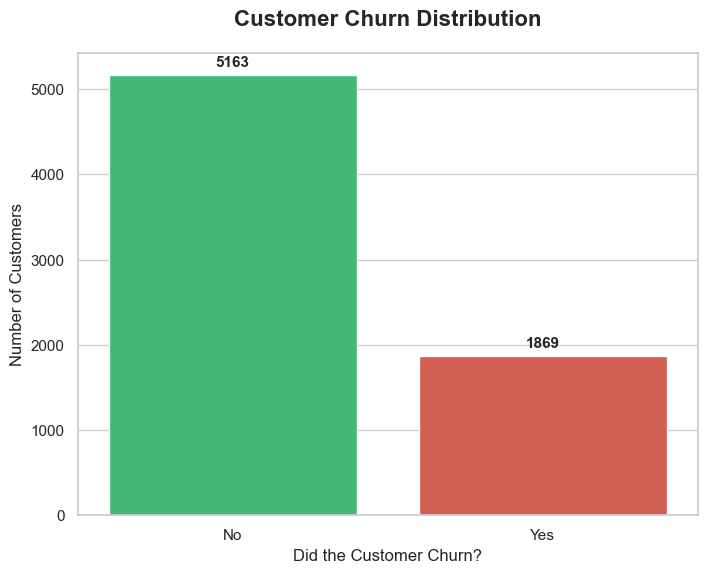

In [33]:
sns.set_theme(style="whitegrid")

# Creating a plot
plt.figure(figsize=(8,6))
ax=sns.countplot(data=df, x='Churn',
hue='Churn', palette=['#2ecc71', '#e74c3c'], legend = False) # green for no, red for yes

# Adding titles and lables
plt.title('Customer Churn Distribution',
fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Did the Customer Churn?',
fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Adding the actual numbers on the top of the bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
    (p.get_x()+p.get_width()/2.,
p.get_height()),
    ha = 'center', va = 'center',
    xytext = (0,9),
    textcoords = 'offset points',
    fontsize = 11, fontweight='bold')
plt.savefig('../charts/churn_distribution.png',
    dpi=150,
    bbox_inches='tight'
)    

plt.show()

Although retained customers are higher, churned customers still form a large enough group to impact business revenue.

# Churn By Contract Type

In [35]:
churn_by_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()

# # churn_by_contract

# month-to-month customers churn most

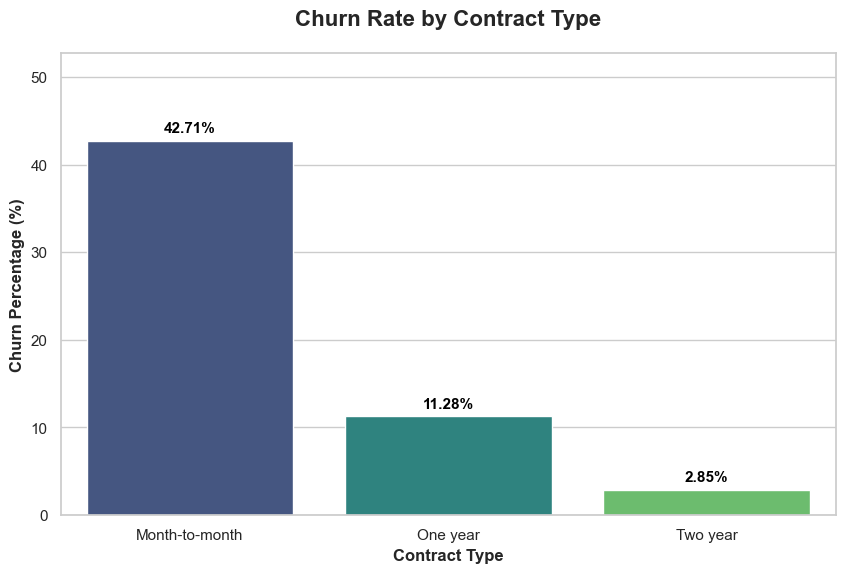

In [50]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=churn_by_contract,
    x='Contract',
    y='Churn',
    palette='viridis',
    hue='Contract',
    legend=False
)

plt.title('Churn Rate by Contract Type',
fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Churn Percentage (%)', fontsize=12,
fontweight='bold')
plt.xlabel('Contract Type', fontsize=12,
fontweight='bold')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
            (p.get_x()+p.get_width()/2.,
    p.get_height()),
            ha='center', va='center',
            xytext=(0,9),
            textcoords='offset points',
            fontsize=11, fontweight='bold',
    color='black')

plt.ylim(0, churn_by_contract['Churn'].max()+10)    

plt.savefig(
    '../charts/churn_by_contract.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

Customers with month-to-month contracts showed significantly higher churn because they had lower long-term commitment.

# ADVANCED EXPLORATORY DATA ANALYSIS (EDA)

# Compared Monthly Charges

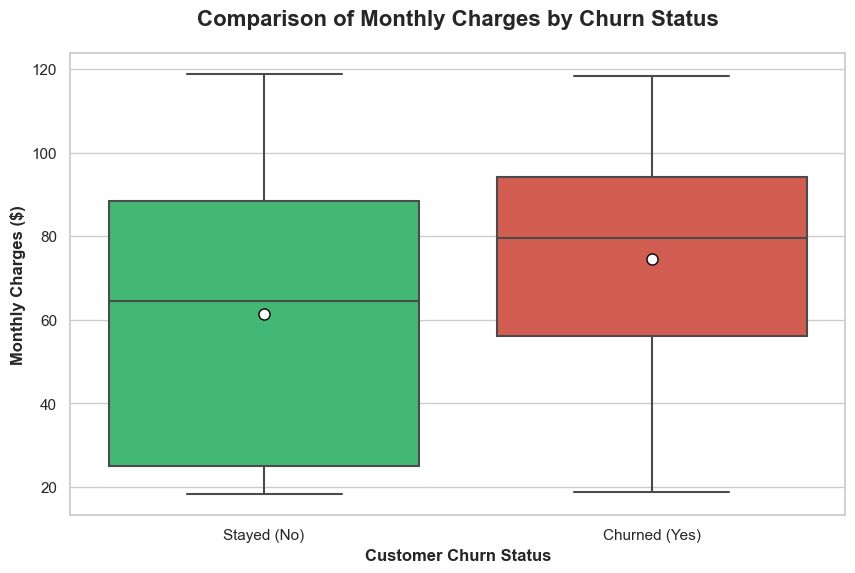

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

ax = sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges',
    palette = ['#2ecc71', '#e74c3c'], # green for no, red for yes
    hue = 'Churn',
    linewidth = 1.5,
    showmeans = True, # Show the mean as a separate marker
    meanprops = {"marker": "o",
    "markerfacecolor": "white",
    "markeredgecolor": "black", "markersize": "8"}
)

plt.title('Comparison of Monthly Charges by Churn Status',
fontsize = 16, fontweight = 'bold', pad = 20)
plt.ylabel('Monthly Charges ($)', fontsize = 12,
fontweight = "bold")
plt.xlabel('Customer Churn Status', fontsize = 12,
fontweight = "bold")
plt.xticks([0,1], ['Stayed (No)', 'Churned (Yes)'])

plt.savefig(
    '../charts/monthly_charges_vs_churn.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

Customers with higher monthly charges tend to churn more frequently.

# Tenure Distribution

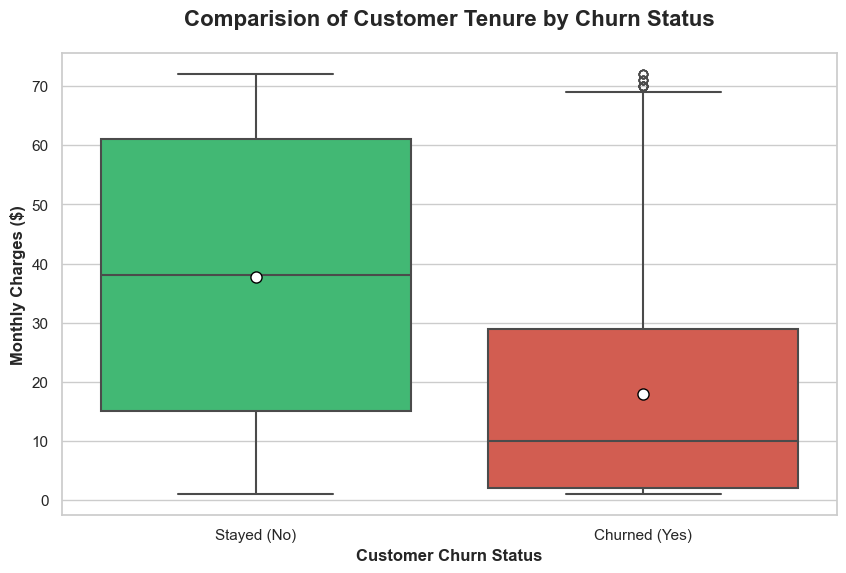

In [54]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure',
    palette = ['#2ecc71', '#e74c3c'], # green for no, red for yes
    hue = 'Churn',
    linewidth = 1.5,
    showmeans = True, # Show the mean as a separate marker
    meanprops = {"marker": "o",
    "markerfacecolor": "white",
    "markeredgecolor": "black", "markersize": "8"}
)

if ax.get_legend():
    ax.get_legend().remove()

plt.title('Comparision of Customer Tenure by Churn Status',
fontsize = 16, fontweight = 'bold', pad = 20)
plt.ylabel('Monthly Charges ($)', fontsize = 12,
fontweight = "bold")
plt.xlabel('Customer Churn Status', fontsize = 12,
fontweight = "bold")
plt.xticks([0,1], ['Stayed (No)', 'Churned (Yes)'])

plt.savefig(
    '../charts/tenure_vs_churn.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Create Payment Method Analysis

In [56]:
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()

In [57]:
payment_churn

,PaymentMethod,Churn
0,Bank transfer (automatic),16.731518
1,Credit card (automatic),15.253123
2,Electronic check,45.285412
3,Mailed check,19.201995


Note: electronic check users churn more

# Visualize Payment Method Churn

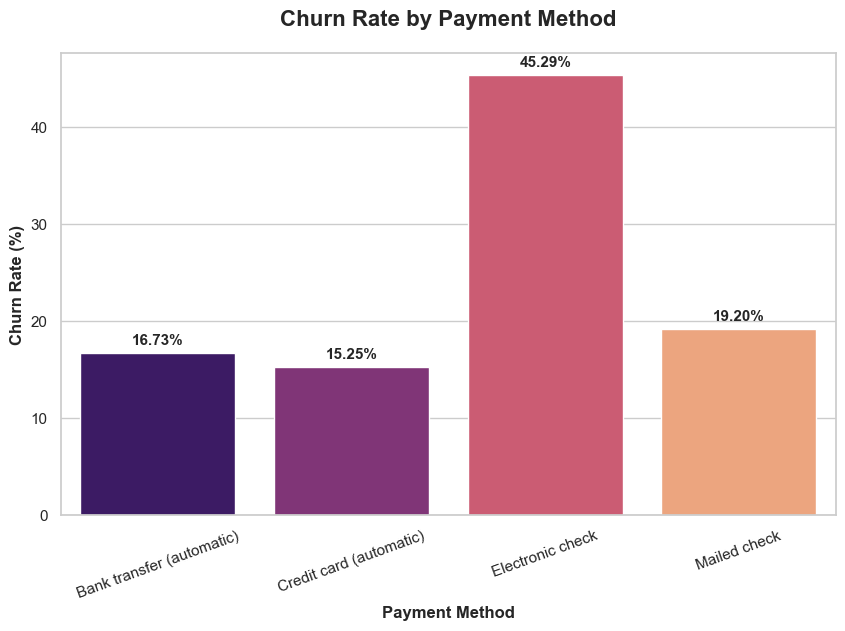

In [70]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=payment_churn,
    x='PaymentMethod',
    y='Churn',
    palette='magma',
    hue='PaymentMethod',
    legend=False
)

plt.title('Churn Rate by Payment Method',
fontsize = 16, fontweight = 'bold', pad = 20)
plt.ylabel('Churn Rate (%)', fontsize = 12,
fontweight = "bold")
plt.xlabel('Payment Method', fontsize = 12,
fontweight = "bold")
plt.xticks(rotation=20)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width() / 2.,
        p.get_height()),
        ha='center', va='center',
        xytext=(0,9),
        textcoords='offset points',
        fontsize=11, fontweight='bold')

plt.savefig(
    '../charts/payment_method_churn.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Internet Service Churn

In [71]:
internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()

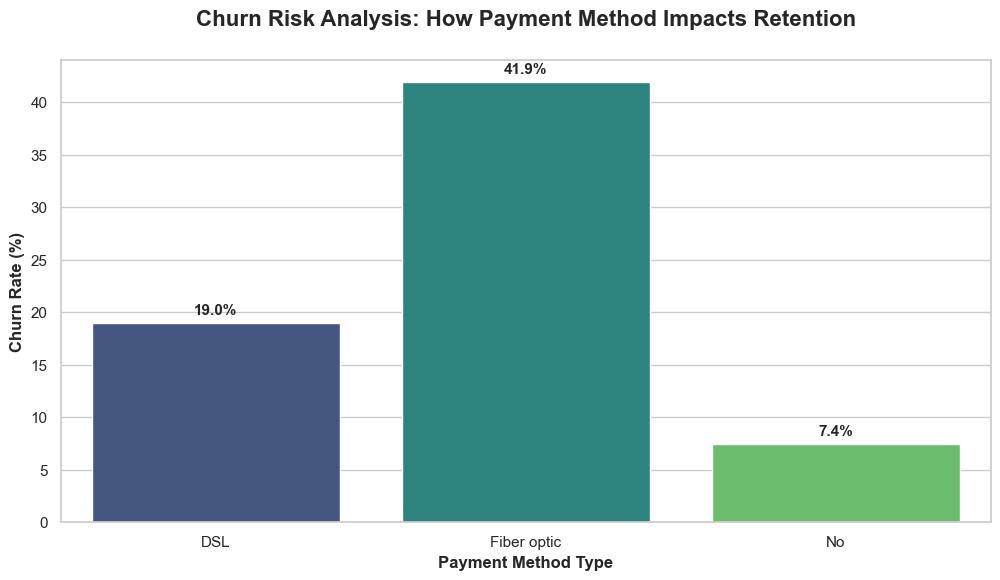

In [73]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

# Sort the data by Churn Rate (Descending)
payment_churn_sorted = payment_churn.sort_values('Churn', ascending=False)

ax = sns.barplot(
    data=internet_churn, 
    x='InternetService', 
    y='Churn', 
    palette='viridis',  # Sophisticated color gradient
    hue='InternetService',
    legend=False
)


plt.title('Churn Risk Analysis: How Payment Method Impacts Retention', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Churn Rate (%)', fontsize=12, fontweight='bold')
plt.xlabel('Payment Method Type', fontsize=12, fontweight='bold')


for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')


plt.savefig('../charts/churn_by_internet_service.png', dpi=300, bbox_inches='tight')

plt.show()

"Fiber Optic Performance vs. Price"

* The Data: You will likely see that Fiber Optic users have a churn rate near 40%, while DSL users are significantly lower (around 15-20%).

* The Insight: Fiber Optic is the fastest service, yet it has the highest churn. This suggests that customers aren't leaving because of the speed, but likely because of the higher price point or perhaps technical issues during setup.

* Actionable Recommendation: The company should look into "Fiber + Content" bundles (like free Netflix or Disney+) to add perceived value to the high cost, or investigate if there are specific regions where Fiber reliability is causing customers to quit.

# CORRELATION HEATMAP

# Convert Churn To Numeric

In [75]:
df['Churn_bin'] = (
    df['Churn'] == 'Yes'
).astype(int)

In [76]:
numeric_df = df.select_dtypes(include='number')

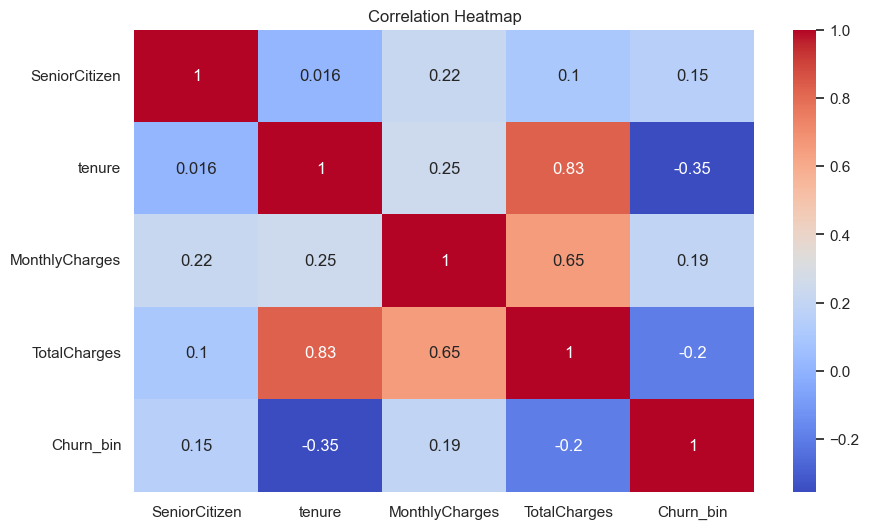

In [80]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.savefig(
    '../charts/correlation_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

Correlation measures the strength and direction of relationship between numerical variables.

Key Insights from the Heatmap

When looking at the Churn column/row in the heatmap, here are the three major insights to document:

1. The Negative Relationship with Tenure (Loyalty is Shielding)
The Data: You’ll see a strong negative correlation (e.g., -0.35) between tenure and Churn.
Insight: This confirms that the longer a customer stays with the company, the less likely they are to leave. Every month a customer stays "de-risks" them.

2. The Positive Relationship with Monthly Charges (Price Sensitivity)
The Data: There is a positive correlation between MonthlyCharges and Churn.
Insight: As the monthly bill goes up, churn risk increases. This supports your earlier finding that Fiber Optic users (who pay more) are leaving at higher rates.

3. Total Charges vs. Tenure (The Sanity Check)
The Data: TotalCharges and tenure will have a very high positive correlation (close to 0.80).
Insight: This is a logical validation of your data—total revenue is a direct product of time spent with the company.